<a href="https://colab.research.google.com/github/geethanjalins/YTRG/blob/main/YouTubeRevenueGenerator(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis


#1.Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#2.Load DataSet

In [ ]:
Youtube_df=pd.read_csv('/content/youtube_ad_revenue_dataset (1).csv',encoding='latin-1')
Youtube_df.head()


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


#3. Understant the DataSet

In [ ]:
Youtube_df.shape

(122400, 12)

In [ ]:
Youtube_df.columns


Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd'],
      dtype='object')

In [ ]:
Youtube_df.dtypes

,0
video_id,object
date,object
views,int64
likes,float64
comments,float64
watch_time_minutes,float64
video_length_minutes,float64
subscribers,int64
category,object
device,object


In [ ]:
Youtube_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


#4.Handle missing values

In [ ]:
Youtube_df.isnull().sum()

,0
video_id,0
date,0
views,0
likes,6117
comments,6112
watch_time_minutes,6105
video_length_minutes,0
subscribers,0
category,0
device,0


In [ ]:
import numpy as np

#Converting the Datatype of likes, comments and watch time
# First, fill NaN values with the mean of each column
Youtube_df['likes'] = Youtube_df['likes'].fillna(Youtube_df['likes'].mean())
Youtube_df['comments'] = Youtube_df['comments'].fillna(Youtube_df['comments'].mean())
Youtube_df['watch_time_minutes'] = Youtube_df['watch_time_minutes'].fillna(Youtube_df['watch_time_minutes'].mean())

# Now convert to int64
Youtube_df['likes']=Youtube_df['likes'].astype('int64')
Youtube_df['comments']=Youtube_df['comments'].astype('int64')
Youtube_df['watch_time_minutes']=Youtube_df['watch_time_minutes'].astype('float64')


In [ ]:
Youtube_df['date'] = pd.to_datetime(Youtube_df['date'])

# 5.Duplicate Detection

In [ ]:
Youtube_df.duplicated().sum()

np.int64(2400)

In [ ]:
Youtube_df.drop_duplicates(inplace=True)

#6. Feature Engineering

In [ ]:
Youtube_df['engagement_rate'] = (Youtube_df['likes'] + Youtube_df['comments']) / Youtube_df['views']

In [ ]:
Youtube_df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.142814
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.236121


#7.Stastical Summary

In [ ]:
Youtube_df.describe()

,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,engagement_rate
count,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,2024-12-08 03:24:11.233198848,9999.832333,1099.555792,274.332350,37540.903811,16.017910,502291.970050,252.711361,0.137395
min,2024-06-09 10:50:40.993199,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603,0.025492
25%,2024-09-07 10:50:40.993199104,9933.000000,673.000000,168.000000,26949.914101,9.005928,252641.500000,199.892158,0.094965
50%,2024-12-08 10:50:40.993199104,10000.000000,1099.000000,274.000000,37543.827721,16.009269,503633.500000,252.678607,0.137421
75%,2025-03-09 10:50:40.993199104,10067.000000,1524.000000,381.000000,48209.880123,23.026064,752386.250000,305.613497,0.179921
max,2025-06-08 10:50:40.993199,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254,0.249554
std,NaN,99.918405,506.371927,126.461529,12658.957084,8.084928,288364.967705,61.954125,0.052160


# Histogram

# Box Plot

In [ ]:
# Numerical columns
num_cols = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers'
]

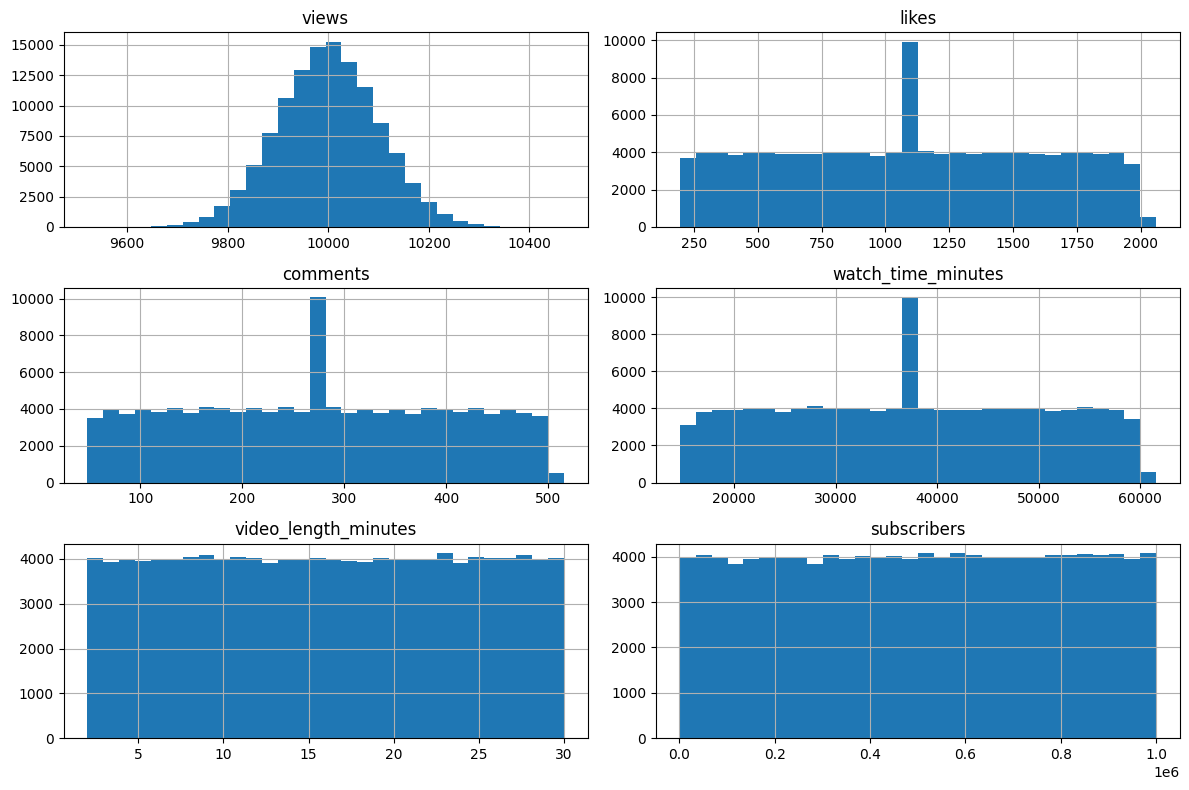

In [ ]:
Youtube_df[num_cols].hist(figsize=(12,8), bins=30)

plt.tight_layout()
plt.show()

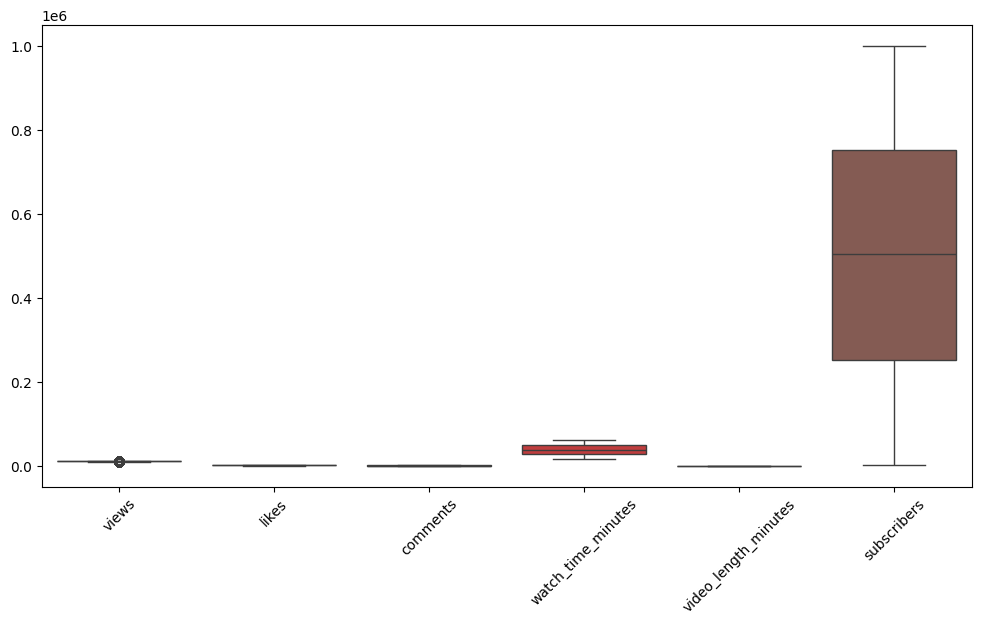

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=Youtube_df[num_cols])

plt.xticks(rotation=45)

plt.show()

In [ ]:
for col in num_cols:

    # Calculate Q1 and Q3
    Q1 = Youtube_df[col].quantile(0.25)
    Q3 = Youtube_df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = Youtube_df[(Youtube_df[col] < lower_limit) | (Youtube_df[col] > upper_limit)]

    print("\n==============================")
    print(f"Column: {col}")
    print(f"Lower Limit: {lower_limit}")
    print(f"Upper Limit: {upper_limit}")
    print(f"Number of Outliers: {len(outliers)}")

    # Display outlier values
    print(outliers[[col]])


Column: views
Lower Limit: 9732.0
Upper Limit: 10268.0
Number of Outliers: 865
        views
119     10273
159      9703
299      9721
301      9708
471     10278
...       ...
121978  10278
122204  10270
122301  10288
122350   9715
122371   9637

[865 rows x 1 columns]

Column: likes
Lower Limit: -603.5
Upper Limit: 2800.5
Number of Outliers: 0
Empty DataFrame
Columns: [likes]
Index: []

Column: comments
Lower Limit: -151.5
Upper Limit: 700.5
Number of Outliers: 0
Empty DataFrame
Columns: [comments]
Index: []

Column: watch_time_minutes
Lower Limit: -4940.034931560509
Upper Limit: 80099.8291551471
Number of Outliers: 0
Empty DataFrame
Columns: [watch_time_minutes]
Index: []

Column: video_length_minutes
Lower Limit: -12.024274214748266
Upper Limit: 44.05626619987166
Number of Outliers: 0
Empty DataFrame
Columns: [video_length_minutes]
Index: []

Column: subscribers
Lower Limit: -496975.625
Upper Limit: 1502003.375
Number of Outliers: 0
Empty DataFrame
Columns: [subscribers]
Index: []

#Removal of outliers

In [ ]:
for col in num_cols:

    Q1 = Youtube_df[col].quantile(0.25)
    Q3 = Youtube_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    Youtube_df = Youtube_df[(Youtube_df[col] >= lower) & (Youtube_df[col] <= upper)]

#8.Numerical and Categorical Columns

In [ ]:
num_cols = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'engagement_rate'
]

In [ ]:
cat_cols = [
    'category',
    'device',
    'country'
]

#Category

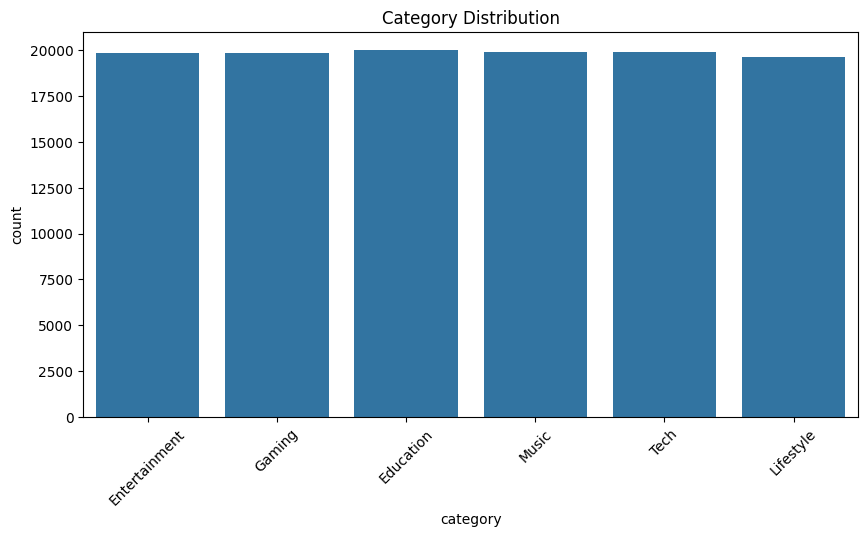

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(x='category', data=Youtube_df)

plt.xticks(rotation=45)

plt.title("Category Distribution")

plt.show()

#Device

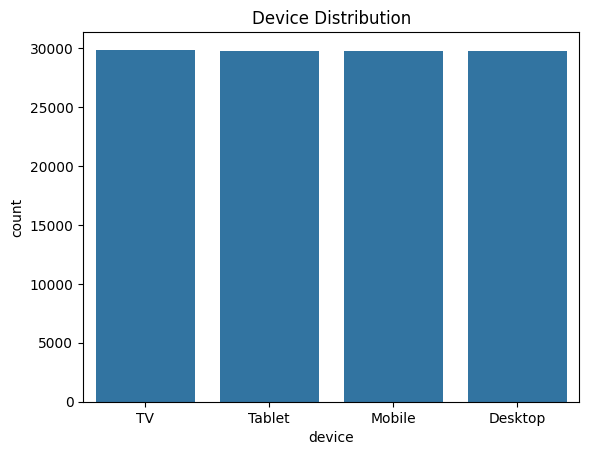

In [ ]:
sns.countplot(x='device', data=Youtube_df)

plt.title("Device Distribution")

plt.show()

#Country

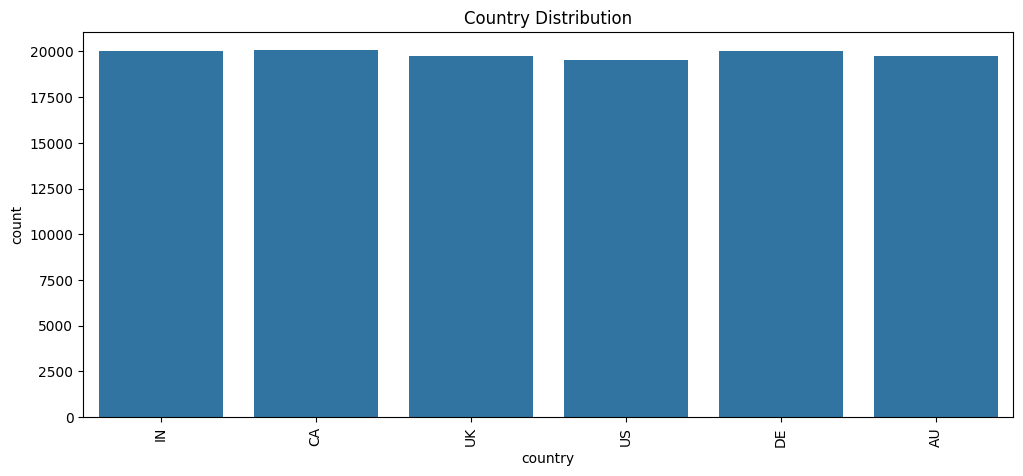

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(x='country', data=Youtube_df)

plt.xticks(rotation=90)

plt.title("Country Distribution")

plt.show()

#9.Bivariate Analysis
Correlation Heatmap

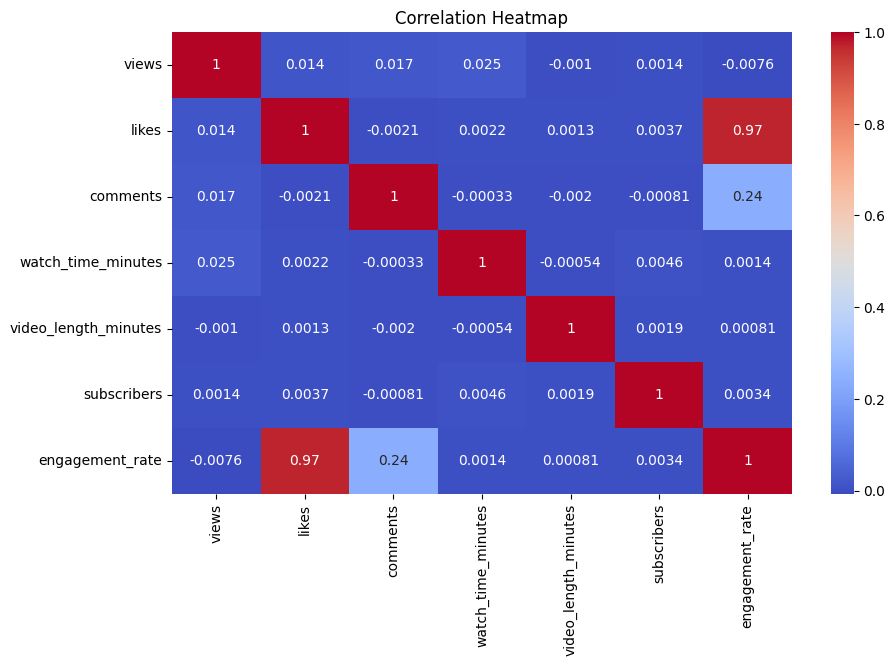

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(Youtube_df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

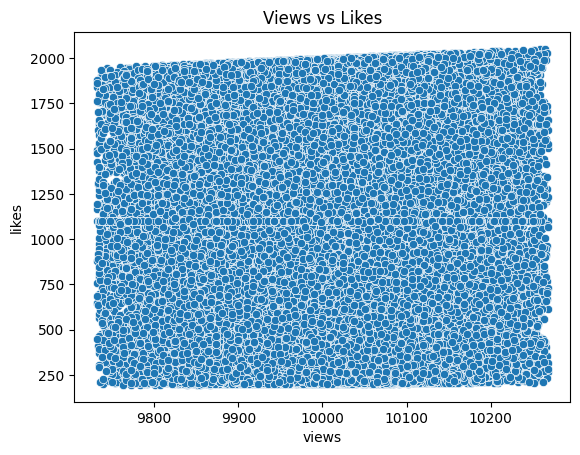

In [ ]:
sns.scatterplot(x='views', y='likes', data=Youtube_df)

plt.title("Views vs Likes")

plt.show()

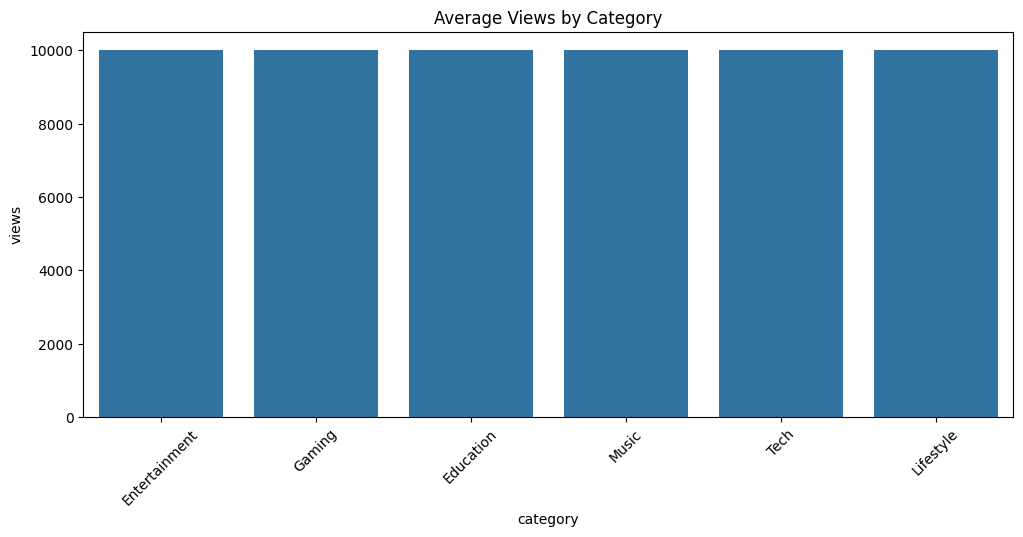

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(x='category',
            y='views',
            data=Youtube_df)

plt.xticks(rotation=45)

plt.title("Average Views by Category")

plt.show()

#10.Encode categorical columns

In [ ]:
cat_cols = ['category', 'device', 'country']

In [ ]:
Youtube_df_encoded = pd.get_dummies(
    Youtube_df,
    columns=cat_cols,
    drop_first=True
)

In [ ]:
Youtube_df_encoded.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,engagement_rate,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,203.178237,0.155093,...,False,False,False,True,False,False,False,True,False,False
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,140.880508,0.098632,...,False,False,False,False,True,True,False,False,False,False
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,360.134008,0.214519,...,False,False,False,True,False,True,False,False,False,False
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,224.638261,0.142814,...,False,False,True,False,False,False,False,False,True,False
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,165.514388,0.236121,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
new_data = Youtube_df_encoded.to_csv('new_data.csv', index=False)

# YouTube Monetization Modeler
This notebook covers the end-to-end process of training a machine learning model to predict YouTube ad revenue based on video performance metrics.

# Model Training

#1.Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

#2.Load Data

In [ ]:
df = pd.read_csv('/content/new_data.csv')
df.head(5)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,engagement_rate,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,203.178237,0.155093,...,False,False,False,True,False,False,False,True,False,False
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,140.880508,0.098632,...,False,False,False,False,True,True,False,False,False,False
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,360.134008,0.214519,...,False,False,False,True,False,True,False,False,False,False
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.77034,434482,224.638261,0.142814,...,False,False,True,False,False,False,False,False,True,False
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,165.514388,0.236121,...,False,False,True,False,False,True,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121029 entries, 0 to 121028
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                121029 non-null  object
 1   date                    121029 non-null  object
 2   views                   121029 non-null  object
 3   likes                   121029 non-null  object
 4   comments                121029 non-null  object
 5   watch_time_minutes      121029 non-null  object
 6   video_length_minutes    121029 non-null  object
 7   subscribers             121029 non-null  object
 8   ad_revenue_usd          121029 non-null  object
 9   engagement_rate         121029 non-null  object
 10  category_Entertainment  121028 non-null  object
 11  category_Gaming         121028 non-null  object
 12  category_Lifestyle      121028 non-null  object
 13  category_Music          121028 non-null  object
 14  category_Tech           121028 non-n

#3.Preprocessing

In [ ]:
# Select the features we want to use for training
# target: 'ad_revenue_usd'
features = ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category_Entertainment','category_Gaming','category_Lifestyle','category_Music','category_Tech','country_CA','country_DE','country_IN','country_UK','country_US'
]
target = 'ad_revenue_usd'

# Create final dataframe
model_df = df[features + [target]].copy()
model_df.to_csv('/content/new_data.csv', index=False)
print(f"Cleaned dataset saved with {len(model_df)} records.")


Cleaned dataset saved with 121029 records.


In [ ]:
numeric_cols_to_convert = ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'ad_revenue_usd']
one_hot_encoded_cols_to_convert = ['category_Entertainment','category_Gaming','category_Lifestyle','category_Music','category_Tech','country_CA','country_DE','country_IN','country_UK','country_US']

for col in numeric_cols_to_convert:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

for col in one_hot_encoded_cols_to_convert:
    # Convert 'True'/'False' strings to 1/0 integers
    model_df[col] = model_df[col].astype(bool).astype(int)

model_df.dropna(inplace=True)

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers']
categorical_features = ['category_Entertainment','category_Gaming','category_Lifestyle','category_Music','category_Tech','country_CA','country_DE','country_IN','country_UK','country_US'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)
    ])

#4.Model trained Evaluation

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, random_state=42)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})
    trained_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
results_df

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Random Forest...
Training Gradient Boosting...


,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.949362,14.013525,3.269039
1,Ridge Regression,0.949362,14.013525,3.269039
2,Lasso Regression,0.948377,14.149160,4.531535
4,Gradient Boosting,0.948144,14.181056,4.589007
3,Random Forest,0.946816,14.361480,3.887386


#5.Model Preservation and Export

In [ ]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")
best_pipeline = trained_pipelines[best_model_name]

joblib.dump(best_pipeline, 'model.pkl')
print("Best model saved as 'model.pkl'.")

Best Model: Linear Regression
Best model saved as 'model.pkl'.
